In [1]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
iris = datasets.load_iris()
print(iris.data[0:5])
print(iris.target[0:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


In [2]:
data = pd.DataFrame(
{'sepal length': iris.data[:, 0], 'sepal width': iris.data[:, 1],
'petal length': iris.data[:, 2], 'petal width': iris.data[:, 3],
'species': iris.target}
)
print(data.head())

   sepal length  sepal width  petal length  petal width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


In [3]:
x = data[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = data['species']
print(x.head())
print(y.head())

   sepal length  sepal width  petal length  petal width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
print(len(x_train))
print(len(x_test))
print(len(y_train))
print(len(y_test))

105
45
105
45


In [5]:
forest = RandomForestClassifier(n_estimators=100, max_features=3)
forest.fit(x_train, y_train)

RandomForestClassifier(max_features=3)

In [6]:
y_pred = forest.predict(x_test)
print(y_pred)
print(list(y_test))
print(metrics.accuracy_score(y_test, y_pred))

[0 0 2 1 2 2 0 2 0 0 1 2 1 2 2 2 0 0 2 0 1 2 1 2 1 0 2 1 0 1 1 2 2 2 0 1 0
 1 1 1 2 2 1 1 2]
[0, 0, 2, 1, 2, 2, 0, 2, 0, 0, 1, 2, 1, 2, 2, 2, 0, 0, 2, 0, 1, 2, 2, 2, 1, 0, 2, 1, 0, 1, 1, 2, 2, 2, 0, 1, 0, 1, 1, 2, 2, 2, 1, 1, 2]
0.9555555555555556


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
iris=sns.load_dataset('iris')
print(iris.tail(6))

     sepal_length  sepal_width  petal_length  petal_width    species
144           6.7          3.3           5.7          2.5  virginica
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


In [8]:
input_var = iris[['sepal_length','sepal_width','petal_length','petal_width']]
target_var = iris['species']

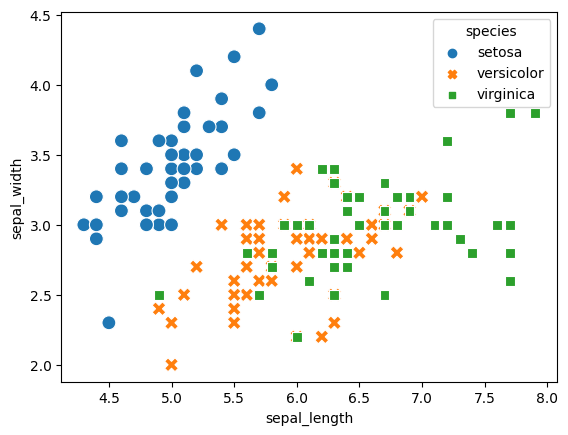

In [9]:
sns.scatterplot(x='sepal_length',
                y='sepal_width',
                hue='species',
                style='species',
                s=100,
                data=iris)
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(input_var)
input_scaled = ss.transform(input_var)
print(input_scaled[0:5,])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(input_scaled)
iris_pca = pca.transform(input_scaled)
print(iris_pca.shape)
print(iris_pca[0:6,])

(150, 2)
[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]
 [-2.07563095  1.48917752]]


In [12]:
import pandas as pd
iris_pca=pd.DataFrame(iris_pca,columns=['pc1','pc2'])
print(iris_pca)

          pc1       pc2
0   -2.264703  0.480027
1   -2.080961 -0.674134
2   -2.364229 -0.341908
3   -2.299384 -0.597395
4   -2.389842  0.646835
..        ...       ...
145  1.870503  0.386966
146  1.564580 -0.896687
147  1.521170  0.269069
148  1.372788  1.011254
149  0.960656 -0.024332

[150 rows x 2 columns]


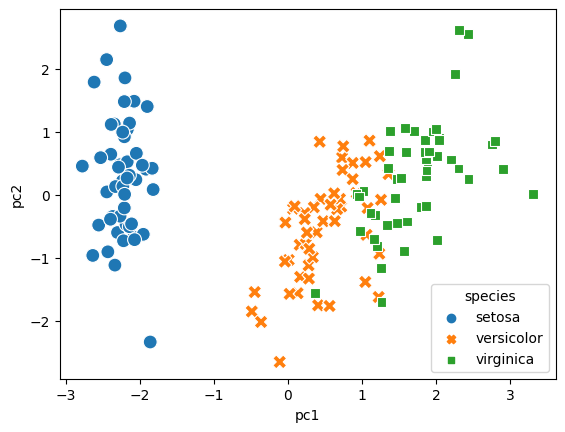

In [13]:
sns.scatterplot(x='pc1',
y='pc2',
hue=target_var, # different colors by group
style=target_var, # different shapes by group
s=100, # marker size
data=iris_pca)
plt.show()

In [14]:
print(pca.explained_variance_ratio_)
import numpy as np
print(np.sum(pca.explained_variance_ratio_))

[0.72962445 0.22850762]
0.9581320720000164


In [15]:
pca_all = PCA(n_components=4)
pca_all.fit(input_scaled)
iris_pca_all = pca_all.transform(input_scaled)
print(iris_pca_all.shape)
print(iris_pca_all[0:6,])
print(pca_all.explained_variance_ratio_)
print(np.sum(pca_all.explained_variance_ratio_))

(150, 4)
[[-2.26470281  0.4800266  -0.12770602 -0.0241682 ]
 [-2.08096115 -0.67413356 -0.23460885 -0.10300677]
 [-2.36422905 -0.34190802  0.04420148 -0.02837705]
 [-2.29938422 -0.59739451  0.09129011  0.06595556]
 [-2.38984217  0.64683538  0.0157382   0.03592281]
 [-2.07563095  1.48917752  0.02696829 -0.00660818]]
[0.72962445 0.22850762 0.03668922 0.00517871]
0.9999999999999999


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import decomposition
from sklearn import datasets
from sklearn.preprocessing import scale
iris = datasets.load_iris()
X = scale(iris.data)
y = iris.target
pca = decomposition.PCA(n_components=2)
X = pca.fit_transform(X)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=iris.feature_names)
loadings

,PC1,PC2
sepal length (cm),0.521066,0.377418
sepal width (cm),-0.269347,0.923296
petal length (cm),0.580413,0.024492
petal width (cm),0.564857,0.066942
